Alaa Ahmed 40490984

## Part 1 — Problem, dataset, and why methylation is the input

This coursework is a supervised classification problem: given a tumour DNA methylation profile, predict one of **eight consensus Group 3/Group 4 medulloblastoma subtypes (I–VIII)**. The subtype labels come from the international meta-analysis that reconciled Group 3/4 heterogeneity into eight robust subtypes using large-scale methylation data.

**What “DNA methylation beta values” mean:** each CpG probe produces a value in **[0, 1]** representing how methylated that genomic site is in the sample. A sample is therefore a very high-dimensional feature vector (hundreds of thousands of probes).

**Why methylation works well here:** the consensus subtypes were derived from high-dimensional methylation profiles, and methylation signatures separate these tumour subtypes reliably at scale.

## Data sources and structure used in this notebook (GSE130051)

The dataset used in this coursework is sourced from GEO series **GSE130051** (referenced by the consensus subtype paper). The cohort size is **1501** samples with subtype labels (I–VIII) for Group 3/4.

Two Illumina array platforms appear in the series:

1) **HM450 (HumanMethylation450)**  
- Provided as a large, already-processed beta-values table (high-dimensional; ~12GB in the supporting workflow we follow).

2) **EPIC (850K)**  
- Provided as raw **IDAT** files (Red/Grn pairs). We generate EPIC beta values ourselves in R using SeSAMe, so we have a genuine cross-platform validation set later.

The coursework requires that we actively curate/prepare the dataset (not treat it as a black box) and then export a clean CSV for downstream modelling in Part 2.

## Biological context

Medulloblastoma is a malignant paediatric brain tumour. Historically it was split into four broad molecular groups; however, **Group 3 and Group 4** contain major heterogeneity. The consensus study analyzed methylation profiles at scale and defined **eight reproducible subtypes (I–VIII)** within Group 3/4, which are the target labels in this coursework.

What matters for this notebook is not the detailed tumour biology, but the **data consequence**:
- subtype labels are derived from methylation patterns, so methylation beta values are the primary predictive signal,
- subtypes are “close” to each other in methylation space (neighbouring subtype confusions are common), which motivates careful preprocessing and robust evaluation later.

## Dataset preparation pipeline (what we did and why)

This Part 1 notebook builds a clean modelling table by combining:
- HM450 beta values (already provided for the cohort),
- EPIC beta values (recomputed from raw IDATs),
then applying consistent filtering so the final dataset is valid, comparable, and ML-ready.

### Output (what Part 1 produces)
The end product of Part 1 is a single clean dataset saved to CSV:
- rows = samples (labelled Group 3/4 tumours),
- columns = filtered CpG beta values (common probes),
- plus the subtype label (I–VIII) for supervised learning in Part 2.

In [45]:
import os
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step A — Metadata acquisition and sample selection (via methylprep)

We used `methylprep` to download and organise the GSE130051 dataset.  
This provided:

- structured metadata,
- sample sheets,
- platform information (HM450 vs EPIC),
- correctly linked IDAT files for EPIC samples.

From the methylprep-generated metadata, we extracted:
- sample IDs,
- platform type,
- consensus subtype labels (I–VIII).

We retained only samples with valid subtype labels, since the downstream task is supervised classification.


run this to get the sample sheets:
```
(base) C:\Users\alaah\Desktop\University\AI for health\Assignment\data>
python -m methylprep meta_data -i GSE130051 -d GSE130051_family.xml\
```

In [3]:
PROJECT = "/content/drive/MyDrive/AI for health/"
DATA_DIR = Path(os.path.join(PROJECT, "data"))
MINML_DIR = Path(os.path.join(DATA_DIR, "GSE130051_family.xml"))
IDAT_DIR = Path(os.path.join(DATA_DIR, "GSE130051_RAW"))

In [4]:
hm450_metadata_samplesheet_file = os.path.join(MINML_DIR, "GSE130051_GPL13534_samplesheet.csv")
epic_metadata_samplesheet_file  = os.path.join(MINML_DIR, "GSE130051_GPL21145_samplesheet.csv")

In [5]:
hm450_metadata = pd.read_csv(hm450_metadata_samplesheet_file)
epic_metadata  = pd.read_csv(epic_metadata_samplesheet_file)

print("HM450:", hm450_metadata.shape)
print("EPIC:", epic_metadata.shape)


HM450: (1391, 15)
EPIC: (110, 15)


From the metadata files we can see that some samples have invalid subtypes, ```MBNOS```, we need to remove samples with this subtype.

In [6]:
print(hm450_metadata["subtype"].value_counts().sort_index())
print(epic_metadata["subtype"].value_counts().sort_index())

subtype
1         41
2        163
3        116
4        131
5        101
6        116
7        281
8        322
MBNOS    120
Name: count, dtype: int64
subtype
1        10
2        14
3         8
4         9
5         7
6         4
7        22
8        25
MBNOS    11
Name: count, dtype: int64


From the metadata files we can see that some samples have invalid subtypes, ```MBNOS```, we need to remove samples with this subtype.

In [ ]:
def get_grn_idat(gsm_id, sentrix_id, sentrix_pos):
    # Common IDAT naming: <something>_<Sentrix_ID>_<Sentrix_Position>_Red.idat and _Grn.idat
    grn = list(IDAT_DIR.glob(f"*{gsm_id}*{sentrix_id}*{sentrix_pos}*Grn.idat.gz"))
    if len(grn) > 1:
        print(f"Warning: Multiple Grn IDATs found for GSM_ID={gsm_id}, Sentrix_ID={sentrix_id}, Sentrix_Position={sentrix_pos}. Files: {grn}")
    elif len(grn) == 1 and not grn[0].exists():
        print(f"Warning: Grn IDAT file not found for GSM_ID={gsm_id}, Sentrix_ID={sentrix_id}, Sentrix_Position={sentrix_pos}.")
    elif len(grn) == 0:
        print(f"Warning: No Grn IDAT found for GSM_ID={gsm_id}, Sentrix_ID={sentrix_id}, Sentrix_Position={sentrix_pos}.")
    return grn[0] if len(grn) > 0 else None  # return first match if exists, else None

def get_red_idat(gsm_id, sentrix_id, sentrix_pos):
    # Common IDAT naming: <something>_<Sentrix_ID>_<Sentrix_Position>_Red.idat and _Grn.idat
    red = list(IDAT_DIR.glob(f"*{gsm_id}*{sentrix_id}*{sentrix_pos}*Red.idat.gz"))
    if len(red) > 1:
        print(f"Warning: Multiple Red IDATs found for GSM_ID={gsm_id}, Sentrix_ID={sentrix_id}, Sentrix_Position={sentrix_pos}. Files: {red}")
    elif len(red) == 1 and not red[0].exists():
        print(f"Warning: Red IDAT file not found for GSM_ID={gsm_id}, Sentrix_ID={sentrix_id}, Sentrix_Position={sentrix_pos}.")
    elif len(red) == 0:
        print(f"Warning: No Red IDAT found for GSM_ID={gsm_id}, Sentrix_ID={sentrix_id}, Sentrix_Position={sentrix_pos}.")

    return red[0] if len(red) > 0 else None  # return first match if exists, else None

needed_cols = {"GSM_ID", "Sentrix_ID", "Sentrix_Position"}

In [ ]:
missing = needed_cols - set(epic_metadata.columns)
if missing:
    raise ValueError(f"EPIC samplesheet missing columns: {missing}. Columns found: {epic_metadata.columns.tolist()[:30]}")

epic_metadata["grn_idat"] = [
    get_grn_idat(str(r.GSM_ID), str(r.Sentrix_ID), str(r.Sentrix_Position))
    for r in epic_metadata.itertuples(index=False)
]

epic_metadata["red_idat"] = [
    get_red_idat(str(r.GSM_ID), str(r.Sentrix_ID), str(r.Sentrix_Position))
    for r in epic_metadata.itertuples(index=False)
]


# if epic_metadata["grn_idat"] and epic_metadata["red_idat"] have null values, issue a warning
if epic_metadata["grn_idat"].isna().any():
    print("Warning: Some EPIC samples are missing Grn IDAT paths.")
if epic_metadata["red_idat"].isna().any():
    print("Warning: Some EPIC samples are missing Red IDAT paths.")

if not epic_metadata["grn_idat"].isna().any() and not epic_metadata["red_idat"].isna().any():
    print("All EPIC samples have both Grn and Red IDAT paths.")

In [ ]:
missing = needed_cols - set(hm450_metadata.columns)
if missing:
    raise ValueError(f"HM450 samplesheet missing columns: {missing}. Columns found: {hm450_metadata.columns.tolist()[:30]}")

hm450_metadata["grn_idat"] = [
    get_grn_idat(str(r.GSM_ID), str(r.Sentrix_ID), str(r.Sentrix_Position))
    for r in hm450_metadata.itertuples(index=False)
]

hm450_metadata["red_idat"] = [
    get_red_idat(str(r.GSM_ID), str(r.Sentrix_ID), str(r.Sentrix_Position))
    for r in hm450_metadata.itertuples(index=False)
]


# if hm450_metadata["grn_idat"] and hm450_metadata["red_idat"] have null values, issue a warning
if hm450_metadata["grn_idat"].isna().any():
    print("Warning: Some HM450 samples are missing Grn IDAT paths.")
if hm450_metadata["red_idat"].isna().any():
    print("Warning: Some HM450 samples are missing Red IDAT paths.")

if not hm450_metadata["grn_idat"].isna().any() and not hm450_metadata["red_idat"].isna().any():
    print("All HM450 samples have both Grn and Red IDAT paths.")

We were successful in finding the IDAT pair files for each sample; each sample has `<prefix>_RED.idat.gz` and `<prefix>_GRN.idat.gz` found in the designated directory

Filter the invalid subtypes

In [7]:
# remove the samples that has a subtype that is not in the set ("1", "2", "3", "4", "5", "6", "7", "8")
valid_subtypes = {"1", "2", "3", "4", "5", "6", "7", "8"}
hm450_metadata = hm450_metadata[hm450_metadata["subtype"].isin(valid_subtypes)]
epic_metadata = epic_metadata[epic_metadata["subtype"].isin(valid_subtypes)]
print("After filtering by valid subtypes:")
print(f"HM450 samples: {len(hm450_metadata)}")
print(f"EPIC samples: {len(epic_metadata)}")

After filtering by valid subtypes:
HM450 samples: 1271
EPIC samples: 99


As per the paper workflow, we have successfully identified **1271** HM450 and **99** EPIC valid samples.

In [8]:
epic_metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 0 to 109
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   GSM_ID                  99 non-null     object
 1   Sample_Name             99 non-null     object
 2   Sentrix_ID              99 non-null     int64 
 3   Sentrix_Position        99 non-null     object
 4   source                  99 non-null     object
 5   cohort                  99 non-null     object
 6   tissue                  99 non-null     object
 7   subgroup                99 non-null     object
 8   subtype                 99 non-null     object
 9   Sample_ID               99 non-null     object
 10  Extract-Protocol        99 non-null     object
 11  Label-Protocol          99 non-null     object
 12  Hybridization-Protocol  99 non-null     object
 13  Scan-Protocol           99 non-null     object
 14  Data-Processing         99 non-null     object
dtypes: int64(1),

We will save the epic metadata dataframe into a `.csv` file to use it later in `R` to process it under `SeSAMe`. Please note that the metadata csv file will contain IDAT pair paths for each valid sample.

In [ ]:
# save the metadata with idat paths for later use
epic_metadata.to_csv(Path(os.path.join(DATA_DIR, "epic_metadata_idat.csv")), index=False)

### Step B — EPIC preprocessing from raw IDATs in R (SeSAMe)
EPIC samples are processed from Red/Grn IDAT pairs to beta values using SeSAMe’s standard flow.

**How “feature selection / probe filtering” maps to SeSAMe functions (explicit mapping):**

1) **Mask poor-quality / problematic probes**  
   - Implemented by: `qualityMask(s)`  
   - What it does (practically): removes probes that are known (from platform design + population genetics + mapping) to be unreliable, e.g., mapping issues, SNP-affected probes, non-unique probes, etc. This corresponds to SeSAMe’s recommended masks (e.g., `"KYCG.EPIC.Mask..."`, `"KYCG.HM450.Mask..."`) that we also export for consistent filtering across platforms.

2) **Infer Infinium-I channel** (technical correction for platform chemistry)  
   - Implemented by: `inferInfiniumIChannel(s)`

3) **Correct dye bias (non-linear)**  
   - Implemented by: `dyeBiasNL(s)`

4) **Detection p-value masking (remove weak/unreliable measurements)**  
   - Implemented by: `pOOBAH(s, pval.threshold=0.05)`  
   - Practical meaning: if a probe’s signal looks indistinguishable from background noise, it is masked out.

5) **Background correction / normalization**  
   - Implemented by: `noob(s)`

6) **Convert to ML features**  
   - Implemented by: `getBetas(s)` which outputs beta values in [0,1].

This sequence is used to ensure EPIC beta values are produced in a way consistent with recommended methylation preprocessing for Illumina arrays.


Run the source code file: `get_epic_beta_values.r` to extract the EPIC beta values from the IDAT pair files.

``` r
suppressPackageStartupMessages({
  library(sesame)
  library(sesameData)
  library(data.table)
})

# =========================
# Paths (edit these)
# =========================
DATA_DIR  <- "data"  # or your DATA_DIR
manifest_path <- file.path(DATA_DIR, "epic_metadata_idat.csv")
out_beta_path <- file.path(DATA_DIR, "EPIC_beta_values_processed.csv.gz")

cat("Working directory:", getwd(), "\n")
cat("Manifest:", normalizePath(manifest_path, winslash = "/", mustWork = FALSE), "\n")

# =========================
# SeSAMe cache safety (optional but helpful)
# =========================
try(sesameDataCache("idatSignature"), silent = TRUE)

# =========================
# Helpers
# =========================
norm_path <- function(p, root = getwd()) {
  p <- gsub("\\\\", "/", p)
  is_abs  <- grepl("^[A-Za-z]:/", p)
  # Only prepend root to relative paths
  p[!is_abs] <- file.path(root, p[!is_abs])
  normalizePath(p, winslash = "/", mustWork = FALSE)
}

to_prefix <- function(idat_path) {
  # Convert:
  #   ..._Red.idat       -> ...
  #   ..._Grn.idat       -> ...
  #   ..._Red.idat.gz    -> ...
  #   ..._Grn.idat.gz    -> ...
  sub("_(Red|Grn)\\.idat(\\.gz)?$", "", idat_path, ignore.case = TRUE)
}

assert_files <- function(dt, red_col, grn_col) {
  ok <- !is.na(dt[[red_col]]) & !is.na(dt[[grn_col]]) &
    file.exists(dt[[red_col]]) & file.exists(dt[[grn_col]])
  if (!all(ok)) {
    bad <- dt[!ok, .(GSM_ID, red = get(red_col), grn = get(grn_col))]
    print(head(bad, 25))
    stop(paste("Some IDAT paths do not exist for", nrow(bad), "samples."))
  }
}

# EPIC pipeline (paper flow)
process_one_prefix <- function(prefix) {
  s <- readIDATpair(prefix)   # prefix shared by _Red/_Grn
  s <- qualityMask(s)
  s <- inferInfiniumIChannel(s)
  s <- dyeBiasNL(s)
  s <- pOOBAH(s, pval.threshold = 0.05)
  s <- noob(s)
  getBetas(s)
}

# Extract chr probes from a sesame manifest (tries to be version-robust)
extract_chr_probes <- function(manifest_obj, chr_name = "chrX") {
  df <- NULL
  if (is.data.frame(manifest_obj)) {
    df <- manifest_obj
  } else {
    df <- tryCatch(as.data.frame(manifest_obj), error = function(e) NULL)
  }
  if (is.null(df)) stop("Could not coerce manifest to data.frame to extract chr probes.")

  if (!("chr" %in% names(df))) stop("Manifest data.frame missing 'chr' column.")
  pid <- if ("Probe_ID" %in% names(df)) df$Probe_ID else rownames(df)
  pid[df$chr == chr_name]
}

get_first_manifest <- function(candidates) {
  keys <- sesameData:::sesameDataList()
  for (k in candidates) {
    if (k %in% keys) {
      cat("Using sesameData key:", k, "\n")
      return(sesameDataGet(k))
    }
  }
  stop("Could not find any candidate manifest in sesameData. Check sesameData:::sesameDataList().")
}

# =========================
# Load manifest (your python output)
# =========================
dt <- fread(manifest_path)

# Ensure expected columns exist (case-insensitive safe)
setnames(dt, names(dt), gsub("\\s+", "_", names(dt)))
# If your CSV has exact names, this won’t change anything.
# We also handle lower/upper variants:
nms <- names(dt)

# Find required columns robustly
col_gsm <- nms[match(TRUE, grepl("^GSM_ID$", nms, ignore.case = TRUE))]
col_red <- nms[match(TRUE, grepl("^red_idat$", nms, ignore.case = TRUE))]
col_grn <- nms[match(TRUE, grepl("^grn_idat$", nms, ignore.case = TRUE))]

if (any(is.na(c(col_gsm, col_red, col_grn)))) {
  stop(paste(
    "Could not find required columns. Need GSM_ID, red_idat, grn_idat.\nColumns found:",
    paste(names(dt), collapse = ", ")
  ))
}

# Standardize names for downstream
setnames(dt, col_gsm, "GSM_ID")
setnames(dt, col_red, "red_idat")
setnames(dt, col_grn, "grn_idat")

cat("Rows in manifest:", nrow(dt), "\n")

# Normalize paths
project_root <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
dt[, red_idat := norm_path(as.character(red_idat), root = project_root)]
dt[, grn_idat := norm_path(as.character(grn_idat), root = project_root)]

# Validate both files exist
assert_files(dt, "red_idat", "grn_idat")

# Build prefixes (prefer using red_idat; should match grn as well)
dt[, idat_prefix := to_prefix(red_idat)]

# Extra safety: check paired files exist for each prefix (handles .idat OR .idat.gz)
pair_exists <- function(prefix) {
  red1 <- paste0(prefix, "_Red.idat")
  grn1 <- paste0(prefix, "_Grn.idat")
  red2 <- paste0(prefix, "_Red.idat.gz")
  grn2 <- paste0(prefix, "_Grn.idat.gz")
  (file.exists(red1) & file.exists(grn1)) | (file.exists(red2) & file.exists(grn2))
}

ok_pair <- vapply(dt$idat_prefix, pair_exists, logical(1))
if (!all(ok_pair)) {
  bad <- dt[!ok_pair, .(GSM_ID, idat_prefix, red_idat, grn_idat)]
  print(head(bad, 25))
  stop(paste("Missing paired IDATs for", nrow(bad), "samples (prefix pairing check)."))
}

# =========================
# Run SeSAMe across samples
# =========================
beta_list <- vector("list", nrow(dt))
names(beta_list) <- dt$GSM_ID

for (i in seq_len(nrow(dt))) {
  gsm <- dt$GSM_ID[i]
  prefix <- dt$idat_prefix[i]

  cat(sprintf("[%d/%d] Processing %s\n", i, nrow(dt), gsm))

  beta_list[[gsm]] <- tryCatch(
    process_one_prefix(prefix),
    error = function(e) {
      cat("FAILED GSM:", gsm, "\n")
      cat("Prefix:", prefix, "\n")
      cat("Red candidates:", paste0(prefix, "_Red.idat"), " OR ", paste0(prefix, "_Red.idat.gz"), "\n")
      cat("Grn candidates:", paste0(prefix, "_Grn.idat"), " OR ", paste0(prefix, "_Grn.idat.gz"), "\n")
      stop(e)
    }
  )
}

# Combine into matrix: probes x samples
beta_matrix <- do.call(cbind, beta_list)
cat("Beta matrix dimensions (probes x samples): ", nrow(beta_matrix), "x", ncol(beta_matrix), "\n")

# Write gz CSV (data.table will gzip if .gz)
out_dt <- as.data.table(beta_matrix, keep.rownames = "probe")
fwrite(out_dt, out_beta_path)
cat("Wrote:", out_beta_path, "\n")
```

Run the source code file: `get_filter_probes.r` to extract the EPIC probes that qualify for masking.

``` r
library(sesameData)

# safest "just make it work" option:
sesameDataCacheAll()

# re-check keys
#keys <- sesameData:::sesameDataList()
#keys[grepl("manifest", keys, ignore.case = TRUE)][1:50]

# chrX/chrY outputs
out_chr_epic_x <- file.path(DATA_DIR, "EPIC_chrX_probes.csv")
out_chr_epic_y <- file.path(DATA_DIR, "EPIC_chrY_probes.csv")
out_chr_450_x  <- file.path(DATA_DIR, "HM450_chrX_probes.csv")
out_chr_450_y  <- file.path(DATA_DIR, "HM450_chrY_probes.csv")

get_xy_from_kycg <- function(key) {
  obj <- sesameDataGet(key)

  # Case 1: already a data.frame/tibble
  if (is.data.frame(obj) || inherits(obj, "tbl")) {
    df <- as.data.frame(obj)

  } else if (is.list(obj)) {
    # Case 2a: list already has probe+chr vectors
    if (!is.null(names(obj)) && all(c("probe", "chr") %in% names(obj))) {
      df <- data.frame(
        probe = as.character(obj$probe),
        chr   = as.character(obj$chr),
        stringsAsFactors = FALSE
      )

    } else {
      # Case 2b: list contains a table as one of its elements
      is_tab <- vapply(obj, function(x) is.data.frame(x) || inherits(x, "tbl"), logical(1))
      if (any(is_tab)) {
        df <- as.data.frame(obj[[which(is_tab)[1]]])

      } else {
        # Case 2c: list might be a mapping like chrX -> probes, chrY -> probes
        nms <- names(obj)
        if (!is.null(nms) && (any(nms %in% c("chrX", "X")) || any(nms %in% c("chrY", "Y")))) {
          chrX <- unique(unlist(obj[nms %in% c("chrX", "X")], use.names = FALSE))
          chrY <- unique(unlist(obj[nms %in% c("chrY", "Y")], use.names = FALSE))
          return(list(chrX = as.character(chrX), chrY = as.character(chrY)))
        }

        stop('Unsupported object returned by sesameDataGet("', key, '"). Class: list (no table/known mapping found).')
      }
    }

  } else {
    stop('Unsupported object returned by sesameDataGet("', key, '"). Class: ', paste(class(obj), collapse=","))
  }

  # --- infer columns in df ---
  probe_col <- intersect(names(df), c("probe","Probe","Probe_ID","IlmnID","Name","ID"))[1]
  chr_col   <- intersect(names(df), c("chr","CHR","chromosome","Chromosome"))[1]

  if (is.na(probe_col) || is.na(chr_col)) {
    stop("Cannot infer probe/chr columns from object. Columns are: ", paste(names(df), collapse=", "))
  }

  chr_vals <- as.character(df[[chr_col]])
  probes   <- as.character(df[[probe_col]])

  list(
    chrX = unique(probes[chr_vals %in% c("chrX","X")]),
    chrY = unique(probes[chr_vals %in% c("chrY","Y")])
  )
}

# EPIC (hg38 available in your list)
epic_xy <- get_xy_from_kycg("KYCG.EPIC.chromosome.hg38.20210630")
# HM450 (hg19 available in your list)
hm450_xy <- get_xy_from_kycg("KYCG.HM450.chromosome.hg19.20210630")

cat("EPIC chrX:", length(epic_xy$chrX), " chrY:", length(epic_xy$chrY), "\n")
cat("HM450 chrX:", length(hm450_xy$chrX), " chrY:", length(hm450_xy$chrY), "\n")

fwrite(data.table(probe = epic_xy$chrX), file.path(DATA_DIR, "EPIC_chrX_probes.csv"))
fwrite(data.table(probe = epic_xy$chrY), file.path(DATA_DIR, "EPIC_chrY_probes.csv"))
fwrite(data.table(probe = hm450_xy$chrX), file.path(DATA_DIR, "HM450_chrX_probes.csv"))
fwrite(data.table(probe = hm450_xy$chrY), file.path(DATA_DIR, "HM450_chrY_probes.csv"))

hm450_mask <- sesameDataGet("KYCG.HM450.Mask.20220123")$recommended
epic_mask  <- sesameDataGet("KYCG.EPIC.Mask.20220123")$recommended

fwrite(data.table(probe = hm450_mask), file.path(DATA_DIR, "HM450_mask_probes.csv"))
fwrite(data.table(probe = epic_mask),  file.path(DATA_DIR, "EPIC_mask_probes.csv"))

cat("HM450 recommended mask probes:", length(hm450_mask), "\n")
cat("EPIC  recommended mask probes:", length(epic_mask), "\n")
```

The `R` scripts will output several files that we use later in this notebook, these files are:
- EPIC_beta_values_processed.csv.gz
- EPIC_chrX_probes.csv (another file for HM450)
- EPIC_chrY_probes.csv (another file for HM450)
- EPIC_mask_probes.csv (another file for HM450)

We are going to process those files in `Python` now to extract the probes that need to be masked

In [9]:
epic_chrX_probes_file = os.path.join(DATA_DIR, "EPIC_chrX_probes.csv")
epic_chrY_probes_file = os.path.join(DATA_DIR, "EPIC_chrY_probes.csv")
hm450_chrX_probes_file = os.path.join(DATA_DIR, "HM450_chrX_probes.csv")
hm450_chrY_probes_file = os.path.join(DATA_DIR, "HM450_chrY_probes.csv")

epic_mask_probes_file = os.path.join(DATA_DIR, "EPIC_mask_probes.csv")
hm450_mask_probes_file = os.path.join(DATA_DIR, "HM450_mask_probes.csv")

In [10]:
epic_chrX_probes = set(pd.read_csv(epic_chrX_probes_file, header=None)[0])
epic_chrY_probes = set(pd.read_csv(epic_chrY_probes_file, header=None)[0])
hm450_chrX_probes = set(pd.read_csv(hm450_chrX_probes_file, header=None)[0])
hm450_chrY_probes = set(pd.read_csv(hm450_chrY_probes_file, header=None)[0])

epic_mask_probes = set(pd.read_csv(epic_mask_probes_file, header=None)[0])
hm450_mask_probes = set(pd.read_csv(hm450_mask_probes_file, header=None)[0])

print(f"EPIC chrX probes: {len(epic_chrX_probes)}")
print(f"EPIC chrY probes: {len(epic_chrY_probes)}")
print(f"HM450 chrX probes: {len(hm450_chrX_probes)}")
print(f"HM450 chrY probes: {len(hm450_chrY_probes)}")

print(f"EPIC mask probes: {len(epic_mask_probes)}")
print(f"HM450 mask probes: {len(hm450_mask_probes)}")

EPIC chrX probes: 17099
EPIC chrY probes: 312
HM450 chrX probes: 9985
HM450 chrY probes: 244
EPIC mask probes: 105455
HM450 mask probes: 64145


In [11]:
epic_drop_probes = epic_chrX_probes.union(epic_chrY_probes).union(epic_mask_probes)
hm450_drop_probes = hm450_chrX_probes.union(hm450_chrY_probes).union(hm450_mask_probes)

print(f"Total EPIC probes to drop: {len(epic_drop_probes)}")
print(f"Total HM450 probes to drop: {len(hm450_drop_probes)}")

Total EPIC probes to drop: 122333
Total HM450 probes to drop: 74036


In [12]:
epic_beta_values_file = os.path.join(DATA_DIR, "EPIC_beta_values_processed.csv.gz")
hm450_beta_values_file = os.path.join(DATA_DIR, "GSE130051_beta_values.csv")

In [13]:
epic_beta = pd.read_csv(epic_beta_values_file)
epic_usecols = [probe for probe in epic_beta['probe'] if probe not in epic_drop_probes and probe.startswith("cg")]
print(f"EPIC columns before dropping: {len(epic_beta['probe'])}")
print(f"EPIC columns after dropping: {len(epic_usecols)}")

EPIC columns before dropping: 866553
EPIC columns after dropping: 741145


In [14]:
hm450_beta_peek = pd.read_csv(hm450_beta_values_file, nrows=1)  # read only header to get columns
hm450_usecols = [probe for probe in hm450_beta_peek.columns if probe not in hm450_drop_probes and probe.startswith("cg")]
print(f"HM450 columns before dropping: {len(hm450_beta_peek.columns)}")
print(f"HM450 columns after dropping: {len(hm450_usecols)}")

HM450 columns before dropping: 453152
HM450 columns after dropping: 381811


We can see that we have the same probe count number as the paper we study did. That means our masking process is doing well.

In [15]:
hm450_valid_samples = set(hm450_metadata['Sample_ID'].astype(str).str.strip())
print(f"Number of valid HM450 samples based on metadata: {len(hm450_valid_samples)}")

Number of valid HM450 samples based on metadata: 1271


Find the common probes between the two platforms

In [ ]:
common_probes = set(epic_usecols).intersection(set(hm450_usecols))
print(len(common_probes))

### Step C — HM450 ingestion (large-file engineering)
HM450 beta values are provided as a very large matrix. To avoid RAM exhaustion, we load the file in **chunks**, keep only:
- samples with valid subtype labels,
- probes we intend to retain after filtering,
then concatenate the retained chunks. This makes the pipeline feasible on limited memory machines.


In [16]:
hm450_chunks = []

chunk_cnt = 0
valid_cnt = 0

reader = pd.read_csv(
    hm450_beta_values_file,
    usecols=common_probes,
    chunksize=1
)

for chunk in tqdm(reader, desc="Reading HM450 chunks"):
    chunk_cnt += 1

    chunk.index = chunk.index.astype(str).str.strip()
    chunk = chunk.loc[chunk.index.intersection(hm450_valid_samples)]

    if not chunk.empty:
        hm450_chunks.append(chunk)
        valid_cnt += 1

hm450_common = pd.concat(hm450_chunks, axis=0)

print("Total chunks processed:", chunk_cnt)
print("Valid chunks kept:", valid_cnt)
print("HM450 loaded (samples x common_probes):", hm450_common.shape)


Reading HM450 chunks: 1501it [2:53:17,  6.93s/it]


Total chunks processed: 1501
Valid chunks kept: 1271
HM450 loaded (samples x common_probes): (1271, 381811)


In [19]:
hm450_beta = hm450_common

Per-sample distribution (quality control)

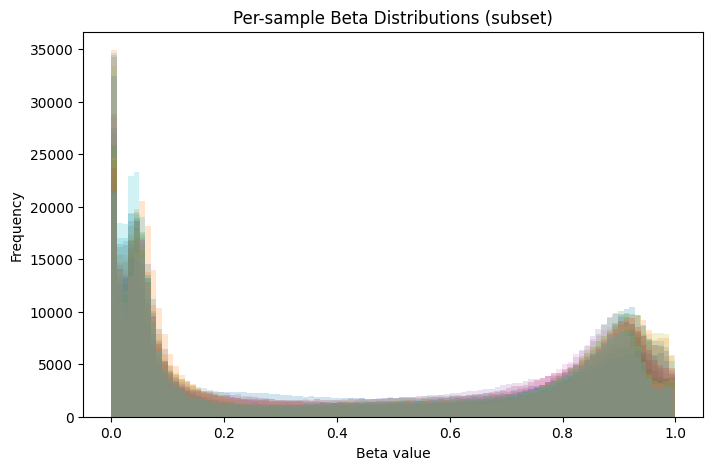

In [ ]:
plt.figure(figsize=(8,5))

for i in range(min(20, hm450_beta.shape[0])):
    plt.hist(hm450_beta.iloc[i], bins=100, alpha=0.2)

plt.xlabel("Beta value")
plt.ylabel("Frequency")
plt.title("Per-sample Beta Distributions (subset)")
plt.show()

Global distribution (all values pooled)

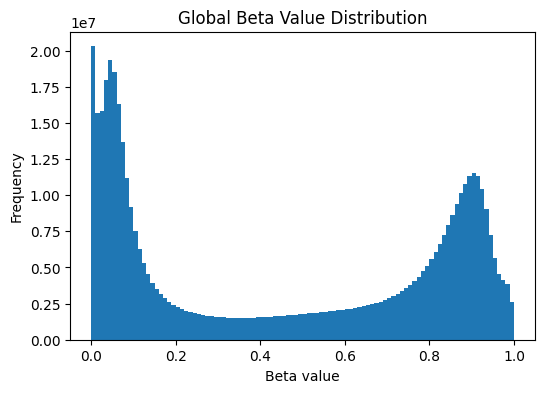

In [ ]:
vals = hm450_beta.to_numpy().ravel()

plt.figure(figsize=(6,4))
plt.hist(vals, bins=100)
plt.xlabel("Beta value")
plt.ylabel("Frequency")
plt.title("Global Beta Value Distribution")
plt.show()

### Step D — Dimensionality Reduction (NMF)

After probe filtering and platform alignment, the dataset remains high-dimensional (thousands of CpG features). To reduce dimensionality, we applied **Non-negative Matrix Factorization (NMF)** with \(k = 20\) components:

\[
X \approx W H
\]

- \(X\): samples × probes  
- \(W\): samples × 20 latent components  
- \(H\): 20 components × probes  

Since methylation beta values are non-negative (0–1), NMF is suitable and produces an additive latent representation of each sample.

Each sample is therefore represented by a 20-dimensional vector (rows of **W**) instead of thousands of CpG features. This reduces complexity and improves stability for downstream modelling.

---

#### Visualization

Two plots were used to inspect the reduced space:

- **2D PCA projection of W**: checks whether subtype structure remains visible after dimensionality reduction.
- **Heatmap of W (samples × components)**: shows activation strength of each latent component per sample, helping verify structured variation across samples.

This step converts the filtered methylation matrix into a compact latent representation suitable for classification.

In [29]:
hm450_labels = hm450_metadata.set_index("Sample_Name")["subtype"].reindex(hm450_beta.index)
hm450_labels = hm450_labels.astype("category")
assert hm450_labels.index.equals(hm450_beta.index)
assert not hm450_labels.isna().any()

In [30]:
hm450_labels.head()

,subtype
6026818126_R01C01,8
6026818126_R04C01,2
6026818136_R01C02,4
6164655140_R01C01,2
6164655140_R03C01,2


In [77]:
# hm450_beta_p: pandas DataFrame (samples x probes), beta values in [0, 1]
hm450_beta_p = hm450_beta[list(common_probes)].astype(np.float32)

# Simple, cheap imputation (per-probe median) if needed
if hm450_beta_p.isna().any().any():
    med = hm450_beta_p.median(axis=0)
    X_df = hm450_beta_p.fillna(med)

# Clip just in case of tiny numeric drift
hm450_beta_p = hm450_beta_p.clip(0.0, 1.0)
hm450_beta_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1271 entries, 6026818126_R01C01 to 9610361022_R03C01
Columns: 381355 entries, cg26727666 to cg08100687
dtypes: float32(381355)
memory usage: 1.8+ GB


In [89]:
epic_beta_p = epic_beta[epic_beta['probe'].isin(common_probes)].copy()
epic_beta_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381355 entries, 0 to 862926
Data columns (total 100 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   probe       381355 non-null  object 
 1   GSM3877742  343463 non-null  float64
 2   GSM3877746  377920 non-null  float64
 3   GSM3877747  375353 non-null  float64
 4   GSM3877748  377639 non-null  float64
 5   GSM3877749  377228 non-null  float64
 6   GSM3877750  343372 non-null  float64
 7   GSM3877751  367493 non-null  float64
 8   GSM3877752  375295 non-null  float64
 9   GSM3877753  378735 non-null  float64
 10  GSM3877754  370490 non-null  float64
 11  GSM3877755  378069 non-null  float64
 12  GSM3877756  365661 non-null  float64
 13  GSM3877757  371111 non-null  float64
 14  GSM3877758  373022 non-null  float64
 15  GSM3877759  363544 non-null  float64
 16  GSM3877760  371596 non-null  float64
 17  GSM3877761  370050 non-null  float64
 18  GSM3877762  376250 non-null  float64
 19  GSM387

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    hm450_beta_p, hm450_labels, test_size=0.2, random_state=40490984, stratify=hm450_labels
)

In [91]:
print(f"X_train size is {X_train.shape}")
print(f"X_test size is {X_test.shape}")
print(f"y_train size is {y_train.shape}")
print(f"y_test size is {y_test.shape}")


X_train size is (1016, 381355)
X_test size is (255, 381355)
y_train size is (1016,)
y_test size is (255,)


In [38]:
k = 20  # number of components

model = NMF(n_components=k, init='random', random_state=40490984, max_iter=1000)
W = model.fit_transform(X_train.to_numpy())
H = model.components_

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


2D projection of W using PCA


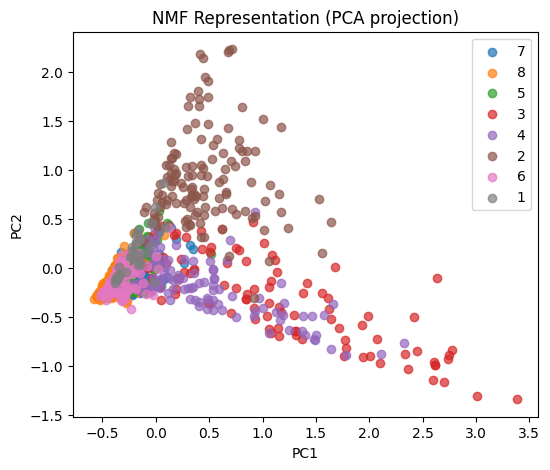

In [42]:
pca = PCA(n_components=2, random_state=42)
W_2d = pca.fit_transform(W)

plt.figure(figsize=(6,5))

for label in y_train.unique():
    idx = (y_train == label)
    plt.scatter(W_2d[idx,0], W_2d[idx,1], label=label, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("NMF Representation (PCA projection)")
plt.legend()
plt.show()

Heatmap of W (samples × components)

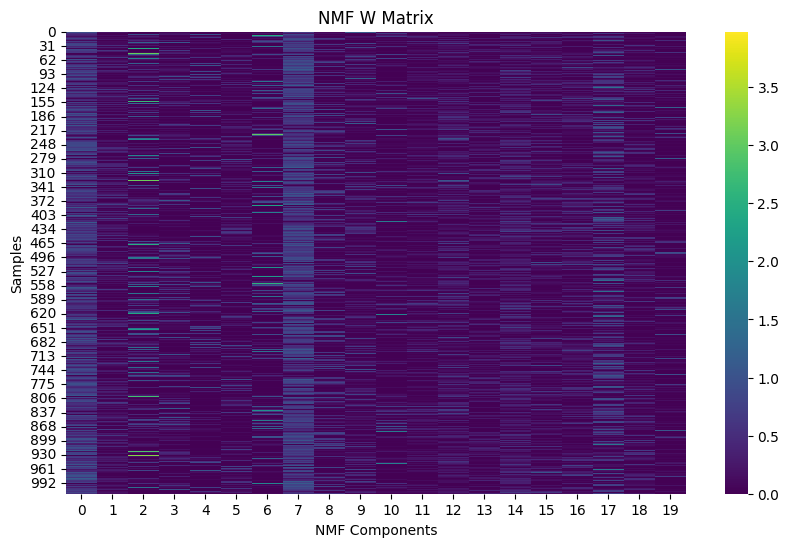

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(W, cmap="viridis")
plt.xlabel("NMF Components")
plt.ylabel("Samples")
plt.title("NMF W Matrix")
plt.show()

Component activation per subtype (interpretability)

/tmp/ipython-input-3038788614.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_activation = W_df.groupby("subtype").mean()


<Figure size 800x500 with 0 Axes>

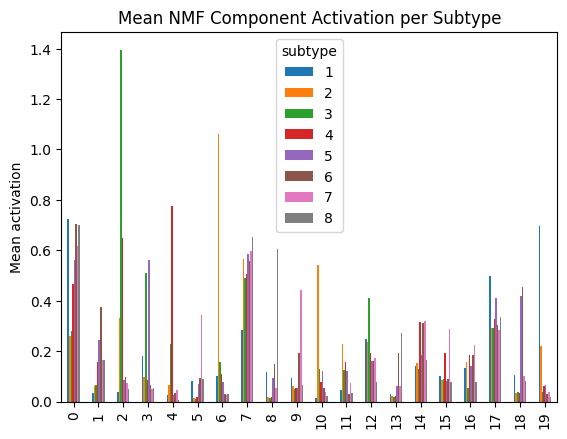

In [46]:
W_df = pd.DataFrame(W, index=y_train.index)
W_df["subtype"] = y_train.values

mean_activation = W_df.groupby("subtype").mean()

plt.figure(figsize=(8,5))
mean_activation.T.plot(kind="bar")
plt.title("Mean NMF Component Activation per Subtype")
plt.ylabel("Mean activation")
plt.show()

Finally, we export the datasets we have into a csv file so that we can handle them in ML pipeline in future work. We have:
- HM450 model training set: "hm450_model_train_set.csv.gz"
- HM450 internal test set: "hm450_internal_test_set.csv.gz"
- EPIC validation set: "epic_validation_set.csv.gz"

In [94]:
X_train.to_csv("hm450_model_train_set.csv")

In [95]:
X_test.to_csv("hm450_internal_test_set.csv")

In [96]:
epic_beta_p.to_csv("epic_validation_set.csv")

## Technical challenges encountered and how they were handled

1) **Extreme dimensionality** (hundreds of thousands of probes)  
Handled by: deterministic probe filtering (quality mask, chrX/chrY removal, CpG-only), then cross-platform intersection.

2) **Large HM450 file size / memory pressure**  
Handled by: chunked loading and filtering during read (keep only valid samples and retained probes), then concatenate.

3) **Cross-platform mismatch (HM450 vs EPIC probe sets)**  
Handled by: intersection of probes to define a consistent feature space.

4) **Label availability / cleanliness**  
Handled by: filtering out samples without subtype labels before final table creation to avoid silent leakage/ambiguity in supervised training.

These decisions follow the coursework requirement to justify filtering, cleaning, and transformation choices as part of dataset curation.